# Lab 04 - Taxi 10x10 ze ścianami

**Workflow:** uruchom komórki od góry. Sekcja **1** definiuje własne środowisko Gymnasium bez importowania lokalnych funkcji ze skryptów. Sekcja **2b** uruchamia trening MaskablePPO na **3_000_000 kroków** i zapisuje modele w `models/`. Sekcja **3** wyświetla **krzywą uczenia**. Sekcja **4** - podgląd ASCII lub gra w oknie pygame.

**Wariant zadania:** siatka `10x10`, stałe przeszkody, losowe rozmieszczenie punktów `R/G/Y/B`, losowy pasażer i cel, bogata obserwacja wektorowa `Box(10,)` oraz shaping nagrody oparty o najkrótszą ścieżkę BFS.

**macOS:** używaj kernela z aktywnego `venv` (`pip install -r requirements.txt`). Opcjonalnie uruchamiaj Jupyter z `./run_train_macos.sh -m jupyter notebook`.


In [55]:
import os
import sys

# macOS + PyTorch: ustaw PRZED importami bibliotek z OpenMP (kernel Jupyter)
if sys.platform == "darwin":
    os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
    os.environ["NUMEXPR_NUM_THREADS"] = "1"
    os.environ["OBJC_DISABLE_INITIALIZE_FORK_SAFETY"] = "YES"

import importlib.util
import subprocess
import time
from collections import deque
from contextlib import closing
from io import StringIO
from pathlib import Path

_REQUIRED_MODULES = [
    "numpy",
    "matplotlib",
    "gymnasium",
    "stable_baselines3",
    "sb3_contrib",
    "torch",
    "tensorboard",
    "pygame",
]
_MISSING = [m for m in _REQUIRED_MODULES if importlib.util.find_spec(m) is None]
if _MISSING:
    print(f"Instaluję brakujące moduły: {_MISSING} …")
    req_file = Path("requirements.txt")
    if req_file.is_file():
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(req_file)])
    else:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q",
            "gymnasium>=0.29", "numpy>=1.26,<3", "matplotlib",
            "stable-baselines3>=2.0", "sb3-contrib>=2.0", "torch>=2.0",
            "tensorboard>=2.14,<3", "pygame>=2.5",
        ])
    print("Instalacja zakończona.")

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from gymnasium import spaces, utils
from sb3_contrib.common.wrappers import ActionMasker

plt.rcParams.update({"figure.dpi": 120, "font.family": "monospace"})

GRID_SIZE = 10
MAX_EPISODE_STEPS = 250
OBSERVATION_MODE = "vector"
MODEL_VARIANT = "v1_10x10_walls_random_locs_vector"
MODEL_DIR = Path("models")
BEST_MODEL_DIR = MODEL_DIR / MODEL_VARIANT
BEST_MODEL_PATH = BEST_MODEL_DIR / "best_model.zip"
FINAL_MODEL_PATH = MODEL_DIR / "custom_grid_taxi_ppo_10x10_walls_random_locs_vector.zip"
LOG_DIR = MODEL_DIR / "logs_10x10_walls_random_locs_vector"

BLOCKED_CELLS = frozenset({
    (1, 3), (2, 3), (3, 3), (4, 3), (6, 3), (7, 3), (8, 3),
    (1, 6), (2, 6), (4, 6), (5, 6), (6, 6), (8, 6),
    (5, 1), (5, 2), (5, 7), (5, 8),
})
LOC_NAMES = ["R", "G", "Y", "B"]
ACTIONS = {0: "S", 1: "N", 2: "E", 3: "W", 4: "PICK", 5: "DROP"}


class NotebookTaxiEnv(gym.Env):
    """Taxi 10x10 ze ścianami, losowymi punktami R/G/Y/B i obserwacją Box(10,)."""

    metadata = {"render_modes": ["ansi", "human", "rgb_array"], "render_fps": 6}

    def __init__(self, render_mode=None, grid_size=GRID_SIZE, randomize_locations=True):
        super().__init__()
        self.render_mode = render_mode
        self.grid_size = int(grid_size)
        self.randomize_locations = bool(randomize_locations)
        self.blocked_cells = set(BLOCKED_CELLS if self.grid_size == 10 else frozenset())
        self.max_row = self.grid_size - 1
        self.max_col = self.grid_size - 1
        self.locs = [(0, 0), (0, self.max_col), (self.max_row, 0), (self.max_row, self.max_col)]
        self._open_cells = [
            (r, c)
            for r in range(self.grid_size)
            for c in range(self.grid_size)
            if (r, c) not in self.blocked_cells
        ]
        self._distance_maps = {cell: self._bfs_distances(cell) for cell in self._open_cells}
        self._max_bfs_distance = max(d for dist_map in self._distance_maps.values() for d in dist_map.values())

        self.action_space = spaces.Discrete(6)
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(10,), dtype=np.float32)

        self.taxi_row = 0
        self.taxi_col = 0
        self.passenger_idx = 0
        self.passenger_start_idx = 0
        self.destination_idx = 0
        self.last_action = None
        self.steps = 0
        self.episode_reward = 0.0

        self._cell = max(20, min(48, 700 // self.grid_size))
        self._hud_h = 96
        self._win_w = self._cell * self.grid_size
        self._win_h = self._cell * self.grid_size + self._hud_h
        self._pygame = None
        self._window = None
        self._clock = None
        self._fonts = {}

    def _is_open_cell(self, row, col):
        return 0 <= row <= self.max_row and 0 <= col <= self.max_col and (row, col) not in self.blocked_cells

    def _neighbors(self, row, col):
        candidates = [(row + 1, col), (row - 1, col), (row, col + 1), (row, col - 1)]
        return [(r, c) for r, c in candidates if self._is_open_cell(r, c)]

    def _bfs_distances(self, target):
        distances = {target: 0}
        queue = deque([target])
        while queue:
            row, col = queue.popleft()
            for nr, nc in self._neighbors(row, col):
                if (nr, nc) not in distances:
                    distances[(nr, nc)] = distances[(row, col)] + 1
                    queue.append((nr, nc))
        return distances

    def _shortest_distance(self, start, target):
        return self._distance_maps[target][start]

    def _sample_locations(self):
        if not self.randomize_locations:
            return list(self.locs)
        idx = self.np_random.choice(len(self._open_cells), size=4, replace=False)
        return [self._open_cells[int(i)] for i in idx]

    def _subgoal_rc(self, pass_idx, dest_idx):
        return self.locs[pass_idx] if pass_idx < 4 else self.locs[dest_idx]

    def _get_obs(self):
        target_r, target_c = self._subgoal_rc(self.passenger_idx, self.destination_idx)
        src_r, src_c = self.locs[self.passenger_start_idx]
        dst_r, dst_c = self.locs[self.destination_idx]
        passenger_state = 0.5 if self.passenger_idx == 4 else 0.0
        bfs_distance = self._shortest_distance((self.taxi_row, self.taxi_col), (target_r, target_c))
        return np.array([
            self.taxi_row / self.max_row,
            self.taxi_col / self.max_col,
            passenger_state,
            src_r / self.max_row,
            src_c / self.max_col,
            dst_r / self.max_row,
            dst_c / self.max_col,
            target_r / self.max_row,
            target_c / self.max_col,
            bfs_distance / self._max_bfs_distance,
        ], dtype=np.float32)

    def _action_mask(self):
        mask = np.zeros(6, dtype=np.int8)
        r, c = self.taxi_row, self.taxi_col
        if self._is_open_cell(r + 1, c): mask[0] = 1
        if self._is_open_cell(r - 1, c): mask[1] = 1
        if self._is_open_cell(r, c + 1): mask[2] = 1
        if self._is_open_cell(r, c - 1): mask[3] = 1
        if self.passenger_idx < 4 and (r, c) == self.locs[self.passenger_idx]: mask[4] = 1
        if self.passenger_idx == 4 and (r, c) == self.locs[self.destination_idx]: mask[5] = 1
        return mask

    def action_masks(self):
        return self._action_mask().astype(bool)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.locs = self._sample_locations()
        self.passenger_idx = int(self.np_random.integers(0, 4))
        self.passenger_start_idx = self.passenger_idx
        dest_choices = [d for d in range(4) if d != self.passenger_idx]
        self.destination_idx = int(self.np_random.choice(dest_choices))
        self.taxi_row, self.taxi_col = self._open_cells[int(self.np_random.integers(0, len(self._open_cells)))]
        self.last_action = None
        self.steps = 0
        self.episode_reward = 0.0
        return self._get_obs(), {"prob": 1.0, "action_mask": self._action_mask()}

    def step(self, action):
        row, col = self.taxi_row, self.taxi_col
        p_idx, d_idx = self.passenger_idx, self.destination_idx
        old_target = self._subgoal_rc(p_idx, d_idx)
        old_dist = self._shortest_distance((row, col), old_target)
        new_row, new_col, new_pass = row, col, p_idx
        reward = -0.2
        terminated = False

        if action == 0 and self._is_open_cell(row + 1, col): new_row = row + 1
        elif action == 1 and self._is_open_cell(row - 1, col): new_row = row - 1
        elif action == 2 and self._is_open_cell(row, col + 1): new_col = col + 1
        elif action == 3 and self._is_open_cell(row, col - 1): new_col = col - 1
        elif action == 4:
            if p_idx < 4 and (row, col) == self.locs[p_idx]:
                new_pass, reward = 4, 10.0
            else:
                reward = -10.0
        elif action == 5:
            if p_idx == 4 and (row, col) == self.locs[d_idx]:
                new_pass, reward, terminated = d_idx, 100.0, True
            else:
                reward = -10.0

        self.taxi_row, self.taxi_col = new_row, new_col
        self.passenger_idx = new_pass
        self.last_action = int(action)
        self.steps += 1

        if action in (0, 1, 2, 3):
            new_dist = self._shortest_distance((new_row, new_col), old_target)
            reward += 2.0 * float(old_dist - new_dist)

        self.episode_reward += reward
        return self._get_obs(), reward, terminated, False, {"prob": 1.0, "action_mask": self._action_mask()}

    def render(self):
        if self.render_mode == "ansi":
            return self._render_text()
        if self.render_mode in ("human", "rgb_array"):
            return self._render_pygame()
        return None

    def close(self):
        if self._window is not None and self._pygame is not None:
            try:
                if self.render_mode == "human":
                    self._pygame.display.quit()
                self._pygame.quit()
            except Exception:
                pass
        self._window = None
        self._pygame = None
        self._clock = None
        self._fonts = {}

    def _render_text(self):
        cells = [["#" if (r, c) in self.blocked_cells else "." for c in range(self.grid_size)] for r in range(self.grid_size)]
        for i, (r, c) in enumerate(self.locs):
            cells[r][c] = LOC_NAMES[i]
        if self.passenger_idx < 4:
            pr, pc = self.locs[self.passenger_idx]
            cells[pr][pc] = "P"
        dr, dc = self.locs[self.destination_idx]
        cells[dr][dc] = "D"
        cells[self.taxi_row][self.taxi_col] = "T" if self.passenger_idx < 4 else "🚕"
        with closing(StringIO()) as out:
            out.write("\n".join(" ".join(row) for row in cells) + "\n")
            if self.last_action is not None:
                out.write(f"({ACTIONS[self.last_action]})\n")
            return out.getvalue()

    def _render_pygame(self):
        try:
            import pygame
        except ImportError as exc:
            raise ImportError("Tryb pygame wymaga pakietu pygame") from exc
        if self._window is None:
            self._pygame = pygame
            pygame.init(); pygame.font.init()
            self._window = pygame.display.set_mode((self._win_w, self._win_h)) if self.render_mode == "human" else pygame.Surface((self._win_w, self._win_h))
            self._clock = pygame.time.Clock()
            self._fonts["small"] = pygame.font.SysFont("Menlo,Monaco,monospace", 16)
            self._fonts["mid"] = pygame.font.SysFont("Menlo,Monaco,monospace", 20, bold=True)
            self._fonts["big"] = pygame.font.SysFont("Menlo,Monaco,monospace", 26, bold=True)
        pygame = self._pygame
        if self.render_mode == "human":
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    self.close(); return None
        canvas, cs, gs = self._window, self._cell, self.grid_size
        canvas.fill((232, 238, 247))
        grid_bg, grid_alt, grid_line = (247, 249, 252), (240, 244, 249), (211, 219, 231)
        wall_color, wall_edge = (45, 53, 67), (25, 30, 40)
        loc_colors = [(220, 60, 60), (60, 180, 75), (240, 200, 40), (60, 120, 220)]
        for r in range(gs):
            for c in range(gs):
                rect = pygame.Rect(c * cs + 2, r * cs + 2, cs - 4, cs - 4)
                if (r, c) in self.blocked_cells:
                    pygame.draw.rect(canvas, wall_color, rect, border_radius=8)
                    pygame.draw.rect(canvas, wall_edge, rect, 2, border_radius=8)
                else:
                    pygame.draw.rect(canvas, grid_alt if (r + c) % 2 else grid_bg, rect, border_radius=7)
                    pygame.draw.rect(canvas, grid_line, rect, 1, border_radius=7)
        for i, (lr, lc) in enumerate(self.locs):
            color = loc_colors[i]
            badge = pygame.Rect(lc * cs + 6, lr * cs + 6, cs - 12, cs - 12)
            pygame.draw.rect(canvas, (255, 255, 255), badge, border_radius=12)
            pygame.draw.rect(canvas, color, badge, 4, border_radius=12)
            label = self._fonts["big"].render(LOC_NAMES[i], True, color)
            canvas.blit(label, label.get_rect(center=badge.center))
        dr, dc = self.locs[self.destination_idx]
        goal_rect = pygame.Rect(dc * cs + 5, dr * cs + 5, cs - 10, cs - 10)
        pygame.draw.rect(canvas, (232, 209, 255), goal_rect, border_radius=14)
        pygame.draw.rect(canvas, (152, 70, 215), goal_rect, 4, border_radius=14)
        if self.passenger_idx < 4:
            pr, pc = self.locs[self.passenger_idx]
            cx, cy = pc * cs + cs // 2, pr * cs + cs // 2 + 8
            pygame.draw.circle(canvas, (36, 48, 64), (cx, cy + 5), cs // 8)
            pygame.draw.circle(canvas, (247, 217, 190), (cx, cy - 7), cs // 11)
        tr, tc = self.taxi_row, self.taxi_col
        taxi_rect = pygame.Rect(tc * cs + cs // 6, tr * cs + cs // 6, cs - cs // 3, cs - cs // 3)
        on_board = self.passenger_idx == 4
        pygame.draw.rect(canvas, (150, 158, 170), taxi_rect.move(3, 4), border_radius=14)
        pygame.draw.rect(canvas, (60, 200, 110) if on_board else (250, 200, 50), taxi_rect, border_radius=12)
        pygame.draw.rect(canvas, (30, 30, 35), taxi_rect, 2, border_radius=12)
        win_rect = pygame.Rect(taxi_rect.x + 6, taxi_rect.y + 6, taxi_rect.w - 12, taxi_rect.h // 2 - 4)
        pygame.draw.rect(canvas, (200, 230, 250), win_rect, border_radius=6)
        t_label = self._fonts["mid"].render("TAXI", True, (30, 30, 35))
        canvas.blit(t_label, t_label.get_rect(center=(taxi_rect.centerx, taxi_rect.centery + taxi_rect.h // 4)))
        hud = pygame.Rect(0, cs * gs, self._win_w, self._hud_h)
        pygame.draw.rect(canvas, (28, 34, 48), hud)
        lines = [
            f"pasażer: {'w taxi' if on_board else LOC_NAMES[self.passenger_idx]}    cel: {LOC_NAMES[self.destination_idx]}    mapa: {gs}x{gs}",
            f"krok: {self.steps}    nagroda: {self.episode_reward:.1f}",
            f"ostatnia akcja: {ACTIONS.get(self.last_action, '-')}"
        ]
        for i, text in enumerate(lines):
            surf = self._fonts["small"].render(text, True, (238, 242, 248))
            canvas.blit(surf, (12, cs * gs + 8 + i * 22))
        if self.render_mode == "human":
            pygame.display.flip(); self._clock.tick(self.metadata["render_fps"]); return None
        rgb = pygame.surfarray.pixels3d(canvas)
        return np.transpose(np.array(rgb), axes=(1, 0, 2))


def make_masked_env(render_mode=None, seed=None):
    env = NotebookTaxiEnv(render_mode=render_mode, grid_size=GRID_SIZE, randomize_locations=True)
    if seed is not None:
        env.reset(seed=seed)
    return ActionMasker(env, lambda e: e.unwrapped.action_masks())

print(f"Python: {sys.executable}")
print("OK - notebook zawiera własną definicję środowiska, bez importu z train.py")
print(f"Wariant: {GRID_SIZE}x{GRID_SIZE}, ściany, losowe R/G/Y/B, obs={OBSERVATION_MODE}")

Python: /Users/antonio/IOwAnalizie/inteligencja_obliczeniowa_w_analizie_danych/lab04/taxi/.venv/bin/python
OK - środowiska zarejestrowane
Siatka domyślna: 20×20  |  trening: 15×15


---
## 1. Środowisko - jeden pasażer, siatka 10x10 ze ścianami

**Siatka 10x10** zawiera stałe przeszkody. Punkty **R, G, Y, B** są losowane na wolnych polach przy każdym resecie, a pasażer i cel są losowane spośród tych punktów. Taksówka startuje z losowego wolnego pola.
Akcje: ruch N/S/E/W, pickup, dropoff. Niedozwolone akcje są maskowane.


In [56]:
# Podgląd środowiska notebookowego: 10x10, ściany, losowe R/G/Y/B
for seed in [7, 8]:
    env_v1 = NotebookTaxiEnv(render_mode="ansi", grid_size=GRID_SIZE, randomize_locations=True)
    obs, info = env_v1.reset(seed=seed)
    print(f"--- seed={seed} ---")
    print(env_v1.render())
    print(f"Punkty R/G/Y/B        : {dict(zip(LOC_NAMES, env_v1.locs))}")
    print(f"Przestrzeń obserwacji : {env_v1.observation_space}")
    print(f"Przestrzeń akcji      : {env_v1.action_space}")
    print(f"Maska akcji           : {info['action_mask']}  (1=dozwolona)")
    env_v1.close()


4444444444444444444444444444444
1853535353535353535353535353571
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1853535353535353535353535353561
4444444444444444444444444444444


Przestrzeń obserwacji : Discrete(4500)
Przestrzeń akcji      : Discrete(6)
Maska akcji           : [1 1 0 0 0 0]  (1=dozwolona)


### Nagrody

| Zdarzenie | Nagroda |
|-----------|--------|
| każdy krok | −0.2 |
| zbliżenie do celu (ruch N/S/E/W) | **+2.0 × (d_stare − d_nowe)** po najkrótszej ścieżce BFS |
| poprawny pickup | **+10** |
| dostawa do celu | **+100** |
| błędny pickup/dropoff | −10 |

Dystans BFS uwzględnia ściany, więc agent dostaje poprawny sygnał nawet wtedy, gdy prosta droga Manhattanem jest zablokowana.


---
## 2. Agent - MaskablePPO

Klasyczny PPO rozszerzony o **maski akcji** - w każdym kroku niedozwolone akcje (np. wjazd w ścianę, pickup gdy nikogo nie ma) są blokowane. Przyspiesza uczenie i eliminuje bezsensowne eksplorowanie.

In [57]:
# Jeden epizod losowej polityki z maskowaniem
# To pokazuje API środowiska i fakt, że akcje wejścia w ścianę są blokowane.
env = NotebookTaxiEnv(render_mode="ansi", grid_size=GRID_SIZE, randomize_locations=True)
obs, info = env.reset(seed=42)

total_r = 0.0
for step in range(1, 80):
    mask = np.asarray(info["action_mask"], dtype=np.int8)
    action = int(env.action_space.sample(mask=mask))
    obs, reward, terminated, truncated, info = env.step(action)
    total_r += reward
    if step <= 8 or terminated:
        print(f"krok {step:2d} | akcja={ACTIONS[action]:4s} | r={reward:+.1f} | suma={total_r:.1f} | mask={mask.tolist()}")
    if terminated:
        print("  -> DOSTAWA! koniec epizodu")
        break

env.close()

krok  1 | akcja=↓S   | r=-1 | suma=-1
krok  2 | akcja=↑N   | r=-1 | suma=-2
krok  3 | akcja=↑N   | r=-1 | suma=-3
krok  4 | akcja=↑N   | r=-1 | suma=-4
krok  5 | akcja=↓S   | r=-1 | suma=-5


---
## 2b. Trening MaskablePPO z notebooka - 3 000 000 kroków

Ta sekcja **nie importuje `train.py`**. Cała logika treningu jest wpisana bezpośrednio w notebooku: tworzenie środowisk, maskowanie akcji, callback ewaluacyjny, zapis modelu i końcowa ewaluacja.

**Konfiguracja:** 1 pasażer, siatka `10x10`, stałe ściany, losowe punkty `R/G/Y/B`, obserwacja `Box(10,)`, shaping BFS.

**Dobrane hiperparametry PPO:**

| Parametr | Wartość | Uzasadnienie |
|---|---:|---|
| `timesteps` | **3 000 000** | dłuższy budżet po wyniku ~75%, celujemy w stabilne 90%+ |
| `n_envs` | **8** | więcej epizodów zbieranych równolegle; na macOS używany `DummyVecEnv` |
| `learning_rate` | **linear 2.5e-4** | łagodniejsze update'y pod koniec treningu |
| `n_steps` | **512** | częstsze aktualizacje dla krótszego epizodu `250` kroków |
| `batch_size` | **256** | stabilne minibatches przy `8 * 512` próbkach na rollout |
| `n_epochs` | **8** | dość dokładne uczenie bez przepisywania polityki |
| `gamma` | **0.99** | krótszy horyzont pasuje do limitu 250 kroków |
| `ent_coef` | **0.01** | eksploracja pickup/dropoff i różnych punktów R/G/Y/B |
| `target_kl` | **0.03** | wczesne zatrzymanie zbyt agresywnych update'ów |
| `net_arch` | **[128, 128]** | wystarczające dla obserwacji wektorowej `Box(10,)` |

Zapisy:
- najlepszy checkpoint: `models/v1_10x10_walls_random_locs_vector/best_model.zip`,
- finalny model: `models/custom_grid_taxi_ppo_10x10_walls_random_locs_vector.zip`,
- logi krzywej uczenia: `models/logs_10x10_walls_random_locs_vector/evaluations.npz`.


In [58]:
from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.callbacks import MaskableEvalCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor


def linear_schedule(initial_value):
    def _schedule(progress_remaining):
        return float(progress_remaining) * initial_value
    return _schedule


def evaluate_model(model, n_episodes=200, seed=123):
    env = make_masked_env(render_mode=None)
    successes = 0
    rewards = []
    lengths = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        total_r = 0.0
        for step in range(1, MAX_EPISODE_STEPS + 1):
            action, _ = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(int(action))
            total_r += reward
            if terminated or truncated:
                successes += int(terminated)
                rewards.append(total_r)
                lengths.append(step)
                break
    env.close()
    return {
        "success_rate": successes / n_episodes,
        "mean_reward": float(np.mean(rewards)),
        "mean_length": float(np.mean(lengths)),
    }


NOTEBOOK_TRAIN = dict(
    grid_size=GRID_SIZE,
    timesteps=3_000_000,
    n_envs=8,
    seed=42,
    final_eval_episodes=500,
)

print("Konfiguracja treningu:", NOTEBOOK_TRAIN)
print(f"Model: {BEST_MODEL_PATH}")
print(f"Logi:  {LOG_DIR / 'evaluations.npz'}")

base_env = NotebookTaxiEnv(grid_size=GRID_SIZE, randomize_locations=True)
check_env(base_env, warn=True)
base_env.close()

use_dummy_vec = sys.platform == "darwin" and NOTEBOOK_TRAIN["n_envs"] > 1
vec_env_cls = DummyVecEnv if use_dummy_vec else None
if use_dummy_vec:
    print("macOS: używam DummyVecEnv, żeby uniknąć problemów z subprocess/OpenMP.")

train_env = make_vec_env(
    lambda: make_masked_env(render_mode=None),
    n_envs=NOTEBOOK_TRAIN["n_envs"],
    seed=NOTEBOOK_TRAIN["seed"],
    vec_env_cls=vec_env_cls,
)
train_env = VecMonitor(train_env)
eval_env = Monitor(make_masked_env(render_mode=None))

MODEL_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

eval_freq = max(2_000, NOTEBOOK_TRAIN["timesteps"] // (40 * NOTEBOOK_TRAIN["n_envs"]))
eval_callback = MaskableEvalCallback(
    eval_env,
    best_model_save_path=str(BEST_MODEL_DIR),
    log_path=str(LOG_DIR),
    eval_freq=eval_freq,
    n_eval_episodes=50,
    deterministic=True,
    render=False,
)

ppo_kwargs = dict(
    learning_rate=linear_schedule(2.5e-4),
    n_steps=512,
    batch_size=256,
    n_epochs=8,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    target_kl=0.03,
    policy_kwargs=dict(net_arch=dict(pi=[128, 128], vf=[128, 128])),
)

model = MaskablePPO("MlpPolicy", train_env, verbose=1, seed=NOTEBOOK_TRAIN["seed"], **ppo_kwargs)
model.learn(total_timesteps=NOTEBOOK_TRAIN["timesteps"], callback=eval_callback)
model.save(FINAL_MODEL_PATH)
print(f"Zapisano finalny model: {FINAL_MODEL_PATH}")

load_path = BEST_MODEL_PATH if BEST_MODEL_PATH.is_file() else FINAL_MODEL_PATH
best_model = MaskablePPO.load(load_path)
final_eval = evaluate_model(best_model, n_episodes=NOTEBOOK_TRAIN["final_eval_episodes"], seed=10_000)
print(f"Najlepszy checkpoint: {load_path}")
print(f"Skuteczność final eval ({NOTEBOOK_TRAIN['final_eval_episodes']} ep.): {100 * final_eval['success_rate']:.1f}%")
print(f"Średnia nagroda: {final_eval['mean_reward']:.1f}")
print(f"Średnia długość epizodu: {final_eval['mean_length']:.1f}")
if final_eval["success_rate"] < 0.9:
    print("Uwaga: poniżej 90%; zwiększ timesteps albo uruchom trening ponownie z większym budżetem.")

train_env.close()
eval_env.close()

result = {
    "best_path": load_path,
    "final_path": FINAL_MODEL_PATH,
    "success_rate": final_eval["success_rate"],
    "model": best_model,
}


Środowisko: v1  |  siatka: 15×15  |  timesteps: 1,500,000  |  n_envs: 4  |  seed: 42
(macOS) VecEnv: DummyVecEnv - brak subprocessów; przy dużym n_envs trening jest wolniejszy, ale stabilniejszy niż SubprocVecEnv.
Using cpu device


/Users/antonio/IOwAnalizie/inteligencja_obliczeniowa_w_analizie_danych/lab04/taxi/.venv/lib/python3.12/site-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x12ff10380> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x1682da780>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 800      |
|    ep_rew_mean     | -800     |
| time/              |          |
|    fps             | 13501    |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 8192     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 800           |
|    ep_rew_mean          | -800          |
| time/                   |               |
|    fps                  | 7395          |
|    iterations           | 2             |
|    time_elapsed         | 2             |
|    total_timesteps      | 16384         |
| train/                  |               |
|    approx_kl            | 0.00012442251 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.642        |
|    explained_variance   | 0.000762      |


---
## 3. Krzywa uczenia

`MaskableEvalCallback` zapisuje ewaluację do `models/logs_10x10_walls_random_locs_vector/evaluations.npz`. Wykres pokazuje **średnią nagrodę** z pasem ±σ, **długość epizodu** oraz **odsetek udanych dostaw**. To jest krzywa uczenia wymagana do oddania notebooka.


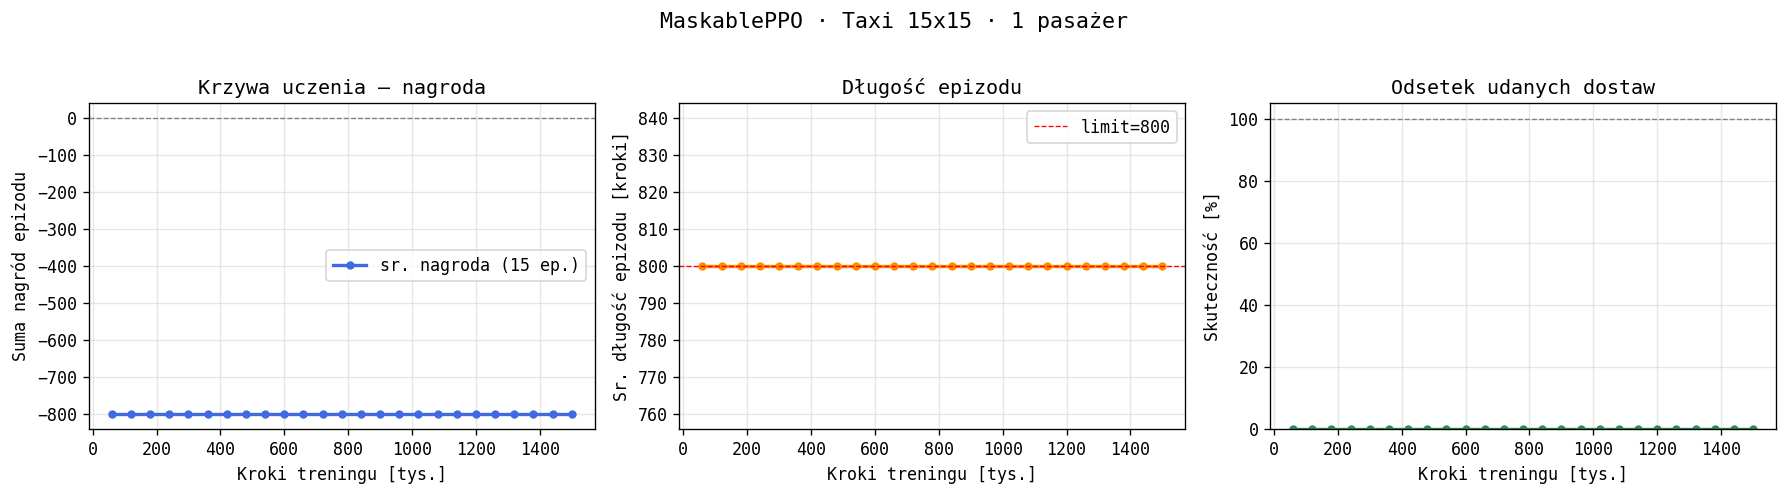

Najlepsza sr. nagroda : -800.0  (przy 60k kroków)
Końcowa skuteczność   : 0%
Końcowa sr. dl. ep.   : 800 kroków


In [59]:
eval_file = LOG_DIR / "evaluations.npz"
if not eval_file.is_file():
    raise FileNotFoundError(f"Brak pliku {eval_file}. Najpierw uruchom sekcję 2b z treningiem.")

data = np.load(eval_file)
ts = data["timesteps"] / 1_000
rewards = data["results"]
lengths = data["ep_lengths"]

mean_r = rewards.mean(axis=1)
std_r = rewards.std(axis=1)
mean_l = lengths.mean(axis=1)
std_l = lengths.std(axis=1)
success_rate_per_ck = (lengths < MAX_EPISODE_STEPS).mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.fill_between(ts, mean_r - std_r, mean_r + std_r, alpha=0.2, color="royalblue")
ax.plot(ts, mean_r, "o-", color="royalblue", lw=2, ms=4, label="sr. nagroda (50 ep.)")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Kroki treningu [tys.]")
ax.set_ylabel("Suma nagród epizodu")
ax.set_title("Krzywa uczenia - nagroda")
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.fill_between(ts, mean_l - std_l, mean_l + std_l, alpha=0.15, color="darkorange")
ax2.plot(ts, mean_l, "o-", color="darkorange", lw=2, ms=4)
ax2.axhline(MAX_EPISODE_STEPS, color="red", lw=0.8, ls="--", label=f"limit={MAX_EPISODE_STEPS}")
ax2.set_xlabel("Kroki treningu [tys.]")
ax2.set_ylabel("Sr. długość epizodu [kroki]")
ax2.set_title("Długość epizodu")
ax2.legend()
ax2.grid(alpha=0.3)

ax3 = axes[2]
ax3.plot(ts, 100 * success_rate_per_ck, "o-", color="seagreen", lw=2, ms=4)
ax3.axhline(90, color="gray", lw=0.9, ls="--", label="cel 90%")
ax3.set_xlabel("Kroki treningu [tys.]")
ax3.set_ylabel("Skuteczność [%]")
ax3.set_title("Odsetek udanych dostaw")
ax3.set_ylim(0, 105)
ax3.legend()
ax3.grid(alpha=0.3)

plt.suptitle("MaskablePPO · Taxi 10x10 walls random-locs · 3M kroków", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

best_idx = mean_r.argmax()
print(f"Najlepsza sr. nagroda : {mean_r[best_idx]:.1f}  (przy {ts[best_idx]:.0f}k kroków)")
print(f"Końcowa skuteczność   : {100 * success_rate_per_ck[-1]:.1f}%")
print(f"Końcowa sr. dł. ep.   : {mean_l[-1]:.1f} kroków")


---
## 4. Ewaluacja wytrenowanego agenta

Po treningu (sekcja **2b**) wczytaj `models/v1_10x10_walls_random_locs_vector/best_model.zip`.

- **`RUN_MODE = "ansi"`** - podgląd tekstowy w notebooku.
- **`RUN_MODE = "human"`** - okno **pygame** (animacja).
- Zmieniaj `SEED`, aby zobaczyć inne losowe rozmieszczenie punktów `R/G/Y/B`, pasażera, celu i taxi.


In [60]:
from sb3_contrib import MaskablePPO

MODEL_PATH = BEST_MODEL_PATH
RUN_MODE = "ansi"   # "ansi" | "human" (pygame)
SEED = 7            # zmień seed, aby dostać inne R/G/Y/B i pozycje startowe
FPS = 6

if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"Brak modelu {MODEL_PATH}. Uruchom najpierw sekcję 2b.")

env = make_masked_env(render_mode=RUN_MODE)
model = MaskablePPO.load(MODEL_PATH)
obs, _ = env.reset(seed=SEED)
total_r = 0.0
limit = MAX_EPISODE_STEPS

print(f"Model: {MODEL_PATH}")
print(f"Seed: {SEED} | punkty R/G/Y/B: {dict(zip(LOC_NAMES, env.unwrapped.locs))}")
if RUN_MODE == "ansi":
    print(env.render())

for step in range(1, limit + 1):
    action, _ = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(int(action))
    total_r += reward
    if RUN_MODE == "ansi":
        if reward > 5 or step <= 5 or terminated or truncated:
            print(f"  krok {step:3d}: {ACTIONS[int(action)]:4s}  r={reward:+.1f}  suma={total_r:.1f}")
        if terminated or truncated:
            print(env.render())
    else:
        env.render()
        time.sleep(max(0.01, 1.0 / FPS))
    if terminated or truncated:
        status = "SUKCES" if terminated else "TIMEOUT"
        print(f"{status}  krok={step}  suma nagród={total_r:.1f}")
        break

env.close()


4444444444444444444444444444444
1853535353535353535353535353571
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1853535353535353535353535353561
4444444444444444444444444444444


  krok   1: N     r=-1  suma=-1
  krok   2: N     r=-1  suma=-2
  krok   3: N     r=-1  suma=-3
4444444444444444444444444444444
1853535353535353535353535353571
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
1353535353535353535353535353531
135353